In [24]:
import math
import time
import random
from collections import defaultdict, deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

FAST_MODE = True

# Tuned so the TD methods are strong enough to present, but still runnable.
CFG = {
    'q1_episodes': 5000 if FAST_MODE else 9000,
    'q1_qlearning_episodes': 8000 if FAST_MODE else 12000,
    'q2_episodes': 5000 if FAST_MODE else 9000,
    'q3_episodes': 5000 if FAST_MODE else 9000,
    'mc_episodes_small': 1500 if FAST_MODE else 3000,
    'task4_proxy_episodes': 1000 if FAST_MODE else 2000,
    'task4_eval_episodes': 150,
    'eval_episodes': 200,
    'max_steps_small': 200,
}
print('FAST_MODE =', FAST_MODE)
print(CFG)


FAST_MODE = True
{'q1_episodes': 5000, 'q1_qlearning_episodes': 8000, 'q2_episodes': 5000, 'q3_episodes': 5000, 'mc_episodes_small': 1500, 'task4_proxy_episodes': 1000, 'task4_eval_episodes': 150, 'eval_episodes': 200, 'max_steps_small': 200}


## helper functions

In [25]:


# Shared helper functions

def make_rng(seed=None):
    return random.Random(SEED if seed is None else seed)


def epsilon_greedy(q_values, epsilon, rng):
    if rng.random() < epsilon:
        return rng.randrange(len(q_values))
    best = np.max(q_values)
    best_actions = [a for a, v in enumerate(q_values) if v == best]
    return rng.choice(best_actions)


def moving_average(values, window=50):
    if len(values) == 0:
        return np.array([])
    window = max(1, min(window, len(values)))
    kernel = np.ones(window) / window
    return np.convolve(np.asarray(values, dtype=float), kernel, mode='valid')


def plot_learning_curves(curve_dict, title, ylabel='Return', window=50):
    plt.figure(figsize=(9, 4))
    for name, values in curve_dict.items():
        ma = moving_average(values, window=window)
        if len(ma) == 0:
            continue
        xs = np.arange(len(ma)) + window
        plt.plot(xs, ma, label=name)
    plt.title(title)
    plt.xlabel('Episode')
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def greedy_policy_from_q(Q):
    policy = {}
    for s, q in Q.items():
        policy[s] = int(np.argmax(q))
    return policy


def evaluate_policy(env, policy=None, Q=None, episodes=100, max_steps=200, seed=123):
    rng = make_rng(seed)
    returns = []
    successes = 0
    lengths = []

    for _ in range(episodes):
        state = env.reset(rng)
        done = False
        total = 0.0
        steps = 0
        while not done and steps < max_steps:
            if Q is not None:
                q_values = Q[state]
                action = int(np.argmax(q_values))
            else:
                action = policy.get(state, 0)
            next_state, reward, done, info = env.step(state, action, rng)
            total += reward
            state = next_state
            steps += 1
        returns.append(total)
        lengths.append(steps)
        if info.get('success', False):
            successes += 1

    return {
        'avg_return': float(np.mean(returns)),
        'success_rate': float(successes / episodes),
        'avg_steps': float(np.mean(lengths))
    }


def summarize_results(rows, title='Results Summary'):
    df = pd.DataFrame(rows)
    if len(df) == 0:
        return df
    print(title)
    display(df)
    return df


## MDP solvers and TD control

In [26]:

# finite-MDP solvers 

def value_iteration(env, gamma=0.95, theta=1e-6, max_iters=500):
    V = {s: 0.0 for s in env.states}
    deltas = []
    start = time.time()

    for _ in range(max_iters):
        delta = 0.0
        newV = dict(V)
        for s in env.states:
            best = -1e18
            best_a = 0
            for a in range(env.n_actions):
                q = 0.0
                for p, ns, r, done in env.model_transitions(s, a):
                    q += p * (r if done else (r + gamma * V[ns]))
                if q > best:
                    best = q
                    best_a = a
            newV[s] = best
            delta = max(delta, abs(best - V[s]))
        V = newV
        deltas.append(delta)
        if delta < theta:
            break

    policy = {}
    for s in env.states:
        best = -1e18
        best_a = 0
        for a in range(env.n_actions):
            q = 0.0
            for p, ns, r, done in env.model_transitions(s, a):
                q += p * (r if done else (r + gamma * V[ns]))
            if q > best:
                best = q
                best_a = a
        policy[s] = best_a
    return V, policy, deltas, time.time() - start


def policy_iteration(env, gamma=0.95, theta=1e-6, max_policy_iters=80, max_eval_iters=500):
    rng = make_rng(999)
    policy = {s: rng.randrange(env.n_actions) for s in env.states}
    V = {s: 0.0 for s in env.states}
    start = time.time()
    stable_iter = 0

    for it in range(max_policy_iters):
        # policy evaluation
        for _ in range(max_eval_iters):
            delta = 0.0
            newV = dict(V)
            for s in env.states:
                a = policy[s]
                v = 0.0
                for p, ns, r, done in env.model_transitions(s, a):
                    v += p * (r if done else (r + gamma * V[ns]))
                newV[s] = v
                delta = max(delta, abs(v - V[s]))
            V = newV
            if delta < theta:
                break

        stable = True
        for s in env.states:
            old = policy[s]
            best = -1e18
            best_a = old
            for a in range(env.n_actions):
                q = 0.0
                for p, ns, r, done in env.model_transitions(s, a):
                    q += p * (r if done else (r + gamma * V[ns]))
                if q > best:
                    best = q
                    best_a = a
            policy[s] = best_a
            if best_a != old:
                stable = False
        stable_iter = it + 1
        if stable:
            break

    return V, policy, stable_iter, time.time() - start


# model-free control

def train_sarsa(env, episodes, alpha=0.1, gamma=0.95, epsilon=0.2,
                epsilon_decay=0.995, min_epsilon=0.02, max_steps=200, seed=123):
    rng = make_rng(seed)
    Q = defaultdict(lambda: np.zeros(env.n_actions, dtype=float))
    returns = []

    eps = epsilon
    start_time = time.time()
    for ep in range(episodes):
        s = env.reset(rng)
        a = epsilon_greedy(Q[s], eps, rng)
        total = 0.0
        done = False
        steps = 0

        while not done and steps < max_steps:
            ns, r, done, info = env.step(s, a, rng)
            total += r
            if done:
                target = r
                Q[s][a] += alpha * (target - Q[s][a])
            else:
                na = epsilon_greedy(Q[ns], eps, rng)
                target = r + gamma * Q[ns][na]
                Q[s][a] += alpha * (target - Q[s][a])
                s, a = ns, na
            steps += 1
        returns.append(total)
        eps = max(min_epsilon, eps * epsilon_decay)

    return {
        'Q': Q,
        'returns': returns,
        'time': time.time() - start_time,
        'policy': greedy_policy_from_q(Q)
    }


def train_q_learning(env, episodes, alpha=0.1, gamma=0.95, epsilon=0.2,
                     epsilon_decay=0.995, min_epsilon=0.02, max_steps=200, seed=123):
    rng = make_rng(seed)
    Q = defaultdict(lambda: np.zeros(env.n_actions, dtype=float))
    returns = []

    eps = epsilon
    start_time = time.time()
    for ep in range(episodes):
        s = env.reset(rng)
        total = 0.0
        done = False
        steps = 0
        while not done and steps < max_steps:
            a = epsilon_greedy(Q[s], eps, rng)
            ns, r, done, info = env.step(s, a, rng)
            total += r
            best_next = 0.0 if done else np.max(Q[ns])
            target = r + gamma * best_next
            Q[s][a] += alpha * (target - Q[s][a])
            s = ns
            steps += 1
        returns.append(total)
        eps = max(min_epsilon, eps * epsilon_decay)

    return {
        'Q': Q,
        'returns': returns,
        'time': time.time() - start_time,
        'policy': greedy_policy_from_q(Q)
    }


def train_n_step_sarsa(env, n, episodes, alpha=0.1, gamma=0.95, epsilon=0.2,
                       epsilon_decay=0.995, min_epsilon=0.02, max_steps=200, seed=123):
    rng = make_rng(seed)
    Q = defaultdict(lambda: np.zeros(env.n_actions, dtype=float))
    returns = []
    eps = epsilon
    start_time = time.time()

    for ep in range(episodes):
        S = []
        A = []
        R = [0.0]

        s0 = env.reset(rng)
        a0 = epsilon_greedy(Q[s0], eps, rng)
        S.append(s0)
        A.append(a0)

        T = float('inf')
        t = 0
        total = 0.0
        info = {'success': False}

        while True:
            if t < T:
                st = S[t]
                at = A[t]
                ns, r, done, info = env.step(st, at, rng)
                total += r
                R.append(r)
                if done or t + 1 >= max_steps:
                    T = t + 1
                else:
                    S.append(ns)
                    na = epsilon_greedy(Q[ns], eps, rng)
                    A.append(na)

            tau = t - n + 1
            if tau >= 0:
                G = 0.0
                upper = (tau + n) if T == float('inf') else min(tau + n, int(T))
                for i in range(tau + 1, upper + 1):
                    G += (gamma ** (i - tau - 1)) * R[i]
                if T == float('inf') or tau + n < T:
                    G += (gamma ** n) * Q[S[tau + n]][A[tau + n]]
                Q[S[tau]][A[tau]] += alpha * (G - Q[S[tau]][A[tau]])

            if tau == T - 1:
                break
            t += 1

        returns.append(total)
        eps = max(min_epsilon, eps * epsilon_decay)

    return {
        'Q': Q,
        'returns': returns,
        'time': time.time() - start_time,
        'policy': greedy_policy_from_q(Q)
    }


def monte_carlo_control(env, episodes, gamma=0.95, epsilon=0.2, max_steps=200, seed=123):
    rng = make_rng(seed)
    Q = defaultdict(lambda: np.zeros(env.n_actions, dtype=float))
    returns_sum = defaultdict(float)
    returns_count = defaultdict(int)
    curve = []
    eps = epsilon
    start = time.time()

    for ep in range(episodes):
        s = env.reset(rng)
        episode = []
        total = 0.0
        done = False
        steps = 0
        while not done and steps < max_steps:
            a = epsilon_greedy(Q[s], eps, rng)
            ns, r, done, info = env.step(s, a, rng)
            episode.append((s, a, r))
            total += r
            s = ns
            steps += 1

        G = 0.0
        visited = set()
        for t in range(len(episode) - 1, -1, -1):
            s, a, r = episode[t]
            G = gamma * G + r
            key = (s, a)
            if key not in visited:
                visited.add(key)
                returns_sum[key] += G
                returns_count[key] += 1
                Q[s][a] = returns_sum[key] / returns_count[key]
        curve.append(total)
        eps = max(0.02, eps * 0.999)

    return {
        'Q': Q,
        'returns': curve,
        'time': time.time() - start,
        'policy': greedy_policy_from_q(Q)
    }


## environment

Q1 states = 376  | obstacles = [(3, 2), (7, 7), (7, 8), (8, 7), (8, 9)]


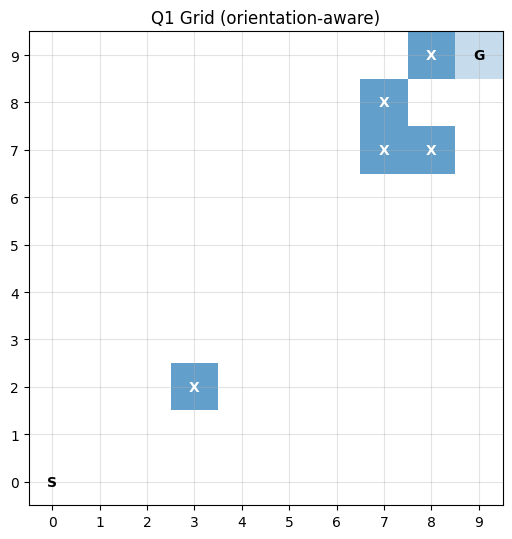

In [27]:

# Q1: Differential-drive robot with orientation-aware planning

class OrientationGridEnv:
    ACTIONS = ['Forward', 'TurnLeft', 'TurnRight']
    DIRS = {
        0: (1, 0),   # East
        1: (0, 1),   # North
        2: (-1, 0),  # West
        3: (0, -1)   # South
    }

    def __init__(self, rows=10, cols=10, seed=11):
        self.rows = rows
        self.cols = cols
        self.n_actions = 3
        self.gamma_default = 0.95
        self.step_reward = -1
        self.collision_reward = -100
        self.goal_reward = 50
        self.goal = (rows - 1, cols - 1)
        self.rng_setup = make_rng(seed)

        protected = {(0, 0), self.goal}
        self.obstacles = set()
        while len(self.obstacles) < 5:
            x = self.rng_setup.randrange(self.cols)
            y = self.rng_setup.randrange(self.rows)
            if (x, y) not in protected:
                self.obstacles.add((x, y))

        self.states = []
        for x in range(self.cols):
            for y in range(self.rows):
                if (x, y) in self.obstacles or (x, y) == self.goal:
                    continue
                for o in range(4):
                    self.states.append((x, y, o))

        self.start_state = (0, 0, 0)
        self.valid_starts = list(self.states)

    def in_bounds(self, x, y):
        return 0 <= x < self.cols and 0 <= y < self.rows and (x, y) not in self.obstacles

    def random_start(self, rng):
        return rng.choice(self.valid_starts)

    def reset(self, rng):
        # Random starts make TD / MC fairer on this large state space
        return self.random_start(rng)

    def _forward_targets(self, x, y, o):
        dx, dy = self.DIRS[o]
        left_o = (o + 1) % 4
        right_o = (o - 1) % 4
        ldx, ldy = self.DIRS[left_o]
        rdx, rdy = self.DIRS[right_o]
        return [
            (0.8, x + dx, y + dy, o),
            (0.1, x + ldx, y + ldy, o),
            (0.1, x + rdx, y + rdy, o),
        ]

    def model_transitions(self, state, action):
        x, y, o = state
        if action == 1:  # TurnLeft
            return [(1.0, (x, y, (o + 1) % 4), self.step_reward, False)]
        if action == 2:  # TurnRight
            return [(1.0, (x, y, (o - 1) % 4), self.step_reward, False)]

        out = []
        for p, nx, ny, no in self._forward_targets(x, y, o):
            if not self.in_bounds(nx, ny):
                out.append((p, state, self.collision_reward, True))
            elif (nx, ny) == self.goal:
                out.append((p, (nx, ny, no), self.goal_reward, True))
            else:
                out.append((p, (nx, ny, no), self.step_reward, False))
        return out

    def step(self, state, action, rng):
        trans = self.model_transitions(state, action)
        probs = [p for p, *_ in trans]
        idx = rng.choices(range(len(trans)), weights=probs, k=1)[0]
        p, ns, r, done = trans[idx]
        info = {'success': done and r == self.goal_reward}
        return ns, r, done, info

    def draw_grid(self):
        plt.figure(figsize=(5.5, 5.5))
        ax = plt.gca()
        ax.set_xlim(-0.5, self.cols - 0.5)
        ax.set_ylim(-0.5, self.rows - 0.5)
        ax.set_xticks(range(self.cols))
        ax.set_yticks(range(self.rows))
        ax.grid(True, alpha=0.35)
        for (x, y) in self.obstacles:
            ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, alpha=0.7))
            ax.text(x, y, 'X', ha='center', va='center', color='white', fontweight='bold')
        gx, gy = self.goal
        ax.add_patch(plt.Rectangle((gx - 0.5, gy - 0.5), 1, 1, alpha=0.25))
        ax.text(gx, gy, 'G', ha='center', va='center', fontweight='bold')
        ax.text(0, 0, 'S', ha='center', va='center', fontweight='bold')
        ax.set_title('Q1 Grid (orientation-aware)')
        ax.set_aspect('equal')
        plt.tight_layout()
        plt.show()


q1_env = OrientationGridEnv()
print('Q1 states =', len(q1_env.states), ' | obstacles =', sorted(q1_env.obstacles))
q1_env.draw_grid()


## Assignment 1 —Question 2 environment

Q2 states = 943  | obstacles = [(0, 8), (1, 8), (3, 6), (4, 9), (5, 8)] | chargers = [(3, 3), (5, 7), (7, 2)]


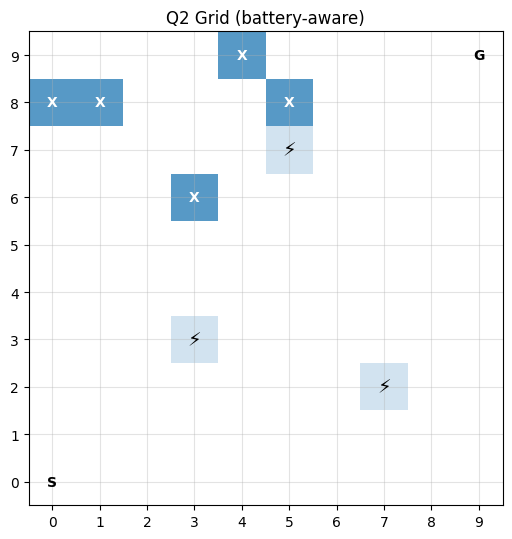

In [28]:

# Q2: Battery-aware robot navigation

class BatteryGridEnv:
    ACTIONS = ['Up', 'Down', 'Left', 'Right', 'Recharge']
    MOVES = {
        0: (0, 1),
        1: (0, -1),
        2: (-1, 0),
        3: (1, 0),
    }

    def __init__(self, rows=10, cols=10, max_battery=10, seed=19):
        self.rows = rows
        self.cols = cols
        self.max_battery = max_battery
        self.n_actions = 5
        self.gamma_default = 0.95
        self.move_reward = -1
        self.recharge_reward = -2
        self.dead_reward = -100
        self.goal_reward = 100
        self.goal = (rows - 1, cols - 1)
        self.start_state = (0, 0, max_battery)
        self.charging = {(3, 3), (7, 2), (5, 7)}
        self.rng_setup = make_rng(seed)

        protected = {(0, 0), self.goal} | set(self.charging)
        self.obstacles = set()
        while len(self.obstacles) < 5:
            x = self.rng_setup.randrange(self.cols)
            y = self.rng_setup.randrange(self.rows)
            if (x, y) not in protected:
                self.obstacles.add((x, y))

        self.states = []
        for x in range(self.cols):
            for y in range(self.rows):
                if (x, y) in self.obstacles or (x, y) == self.goal:
                    continue
                for b in range(self.max_battery + 1):
                    if b == 0 and (x, y) not in self.charging:
                        continue
                    self.states.append((x, y, b))

    def in_bounds(self, x, y):
        return 0 <= x < self.cols and 0 <= y < self.rows and (x, y) not in self.obstacles

    def reset(self, rng):
        return self.start_state

    def model_transitions(self, state, action):
        x, y, b = state

        if action == 4:  # recharge
            if (x, y) in self.charging:
                return [(1.0, (x, y, self.max_battery), self.recharge_reward, False)]
            return [(1.0, state, self.move_reward, False)]

        if b == 0 and (x, y) not in self.charging:
            # not normally entered from nonterminal set, but safe guard
            return [(1.0, state, 0.0, True)]

        dx, dy = self.MOVES[action]
        nx, ny = x + dx, y + dy
        if not self.in_bounds(nx, ny):
            nx, ny = x, y
        nb = max(0, b - 1)

        if (nx, ny) == self.goal:
            return [(1.0, (nx, ny, nb), self.goal_reward, True)]
        if nb == 0 and (nx, ny) not in self.charging:
            return [(1.0, (nx, ny, nb), self.dead_reward, True)]
        return [(1.0, (nx, ny, nb), self.move_reward, False)]

    def step(self, state, action, rng):
        p, ns, r, done = self.model_transitions(state, action)[0]
        info = {'success': done and r == self.goal_reward}
        return ns, r, done, info

    def draw_grid(self):
        plt.figure(figsize=(5.5, 5.5))
        ax = plt.gca()
        ax.set_xlim(-0.5, self.cols - 0.5)
        ax.set_ylim(-0.5, self.rows - 0.5)
        ax.set_xticks(range(self.cols))
        ax.set_yticks(range(self.rows))
        ax.grid(True, alpha=0.35)
        for (x, y) in self.obstacles:
            ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, alpha=0.75))
            ax.text(x, y, 'X', ha='center', va='center', color='white', fontweight='bold')
        for (x, y) in self.charging:
            ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, alpha=0.2))
            ax.text(x, y, '⚡', ha='center', va='center', fontsize=14)
        gx, gy = self.goal
        ax.text(gx, gy, 'G', ha='center', va='center', fontweight='bold')
        ax.text(0, 0, 'S', ha='center', va='center', fontweight='bold')
        ax.set_title('Q2 Grid (battery-aware)')
        ax.set_aspect('equal')
        plt.tight_layout()
        plt.show()


q2_env = BatteryGridEnv()
print('Q2 states =', len(q2_env.states), ' | obstacles =', sorted(q2_env.obstacles), '| chargers =', sorted(q2_env.charging))
q2_env.draw_grid()


## Assignment 1 — Question 3 environment

Q3 states = 94  | obstacles = [(1, 8), (5, 6), (5, 9), (8, 1), (9, 4)]


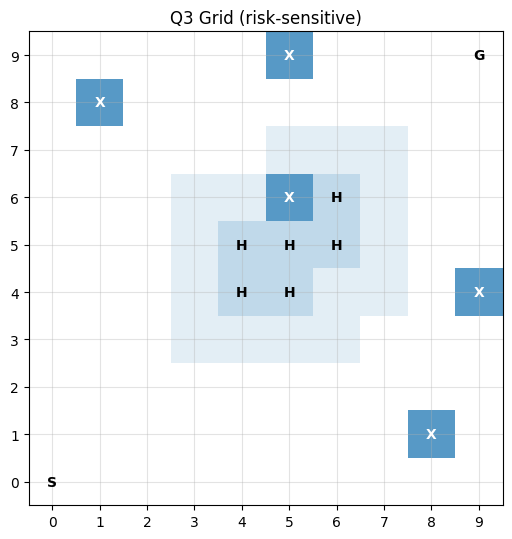

In [29]:

# Q3: Risk-sensitive robot navigation near hazards

class RiskGridEnv:
    ACTIONS = ['Up', 'Down', 'Left', 'Right']
    MOVES = {
        0: (0, 1),
        1: (0, -1),
        2: (-1, 0),
        3: (1, 0),
    }

    def __init__(self, rows=10, cols=10, seed=29,
                 slip_probs=(0.05, 0.15, 0.30)):
        self.rows = rows
        self.cols = cols
        self.n_actions = 4
        self.gamma_default = 0.95
        self.step_reward = -1
        self.goal_reward = 50
        self.catastrophe_reward = -200
        self.goal = (rows - 1, cols - 1)
        self.start_state = (0, 0)
        self.slip_probs = slip_probs
        self.rng_setup = make_rng(seed)

        protected = {(0, 0), self.goal}
        self.obstacles = set()
        while len(self.obstacles) < 5:
            x = self.rng_setup.randrange(self.cols)
            y = self.rng_setup.randrange(self.rows)
            if (x, y) not in protected:
                self.obstacles.add((x, y))

        self.hazard_cells = {(4, 4), (5, 4), (4, 5), (5, 5), (6, 5), (6, 6)}
        self.near_hazard = set()
        for hx, hy in self.hazard_cells:
            for dx in (-1, 0, 1):
                for dy in (-1, 0, 1):
                    nx, ny = hx + dx, hy + dy
                    if 0 <= nx < self.cols and 0 <= ny < self.rows:
                        self.near_hazard.add((nx, ny))
        self.near_hazard -= self.hazard_cells

        self.states = []
        for x in range(self.cols):
            for y in range(self.rows):
                if (x, y) in self.obstacles or (x, y) == self.goal:
                    continue
                self.states.append((x, y))

    def in_bounds(self, x, y):
        return 0 <= x < self.cols and 0 <= y < self.rows and (x, y) not in self.obstacles

    def hazard_level(self, x, y):
        if (x, y) in self.hazard_cells:
            return 2
        if (x, y) in self.near_hazard:
            return 1
        return 0

    def reset(self, rng):
        return self.start_state

    def model_transitions(self, state, action):
        x, y = state
        level = self.hazard_level(x, y)
        p_slip = self.slip_probs[level]
        p_ok = 1.0 - p_slip
        dx, dy = self.MOVES[action]
        nx, ny = x + dx, y + dy
        if not self.in_bounds(nx, ny):
            nx, ny = x, y

        out = []
        if p_slip > 0:
            out.append((p_slip, state, self.catastrophe_reward, True))
        if (nx, ny) == self.goal:
            out.append((p_ok, (nx, ny), self.goal_reward, True))
        else:
            out.append((p_ok, (nx, ny), self.step_reward, False))
        return out

    def step(self, state, action, rng):
        trans = self.model_transitions(state, action)
        probs = [p for p, *_ in trans]
        idx = rng.choices(range(len(trans)), weights=probs, k=1)[0]
        p, ns, r, done = trans[idx]
        info = {'success': done and r == self.goal_reward}
        return ns, r, done, info

    def draw_grid(self):
        plt.figure(figsize=(5.5, 5.5))
        ax = plt.gca()
        ax.set_xlim(-0.5, self.cols - 0.5)
        ax.set_ylim(-0.5, self.rows - 0.5)
        ax.set_xticks(range(self.cols))
        ax.set_yticks(range(self.rows))
        ax.grid(True, alpha=0.35)
        for (x, y) in self.obstacles:
            ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, alpha=0.75))
            ax.text(x, y, 'X', ha='center', va='center', color='white', fontweight='bold')
        for (x, y) in self.near_hazard:
            if (x, y) not in self.obstacles:
                ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, alpha=0.12))
        for (x, y) in self.hazard_cells:
            if (x, y) not in self.obstacles:
                ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, alpha=0.28))
                ax.text(x, y, 'H', ha='center', va='center', fontweight='bold')
        gx, gy = self.goal
        ax.text(gx, gy, 'G', ha='center', va='center', fontweight='bold')
        ax.text(0, 0, 'S', ha='center', va='center', fontweight='bold')
        ax.set_title('Q3 Grid (risk-sensitive)')
        ax.set_aspect('equal')
        plt.tight_layout()
        plt.show()


q3_env = RiskGridEnv()
print('Q3 states =', len(q3_env.states), ' | obstacles =', sorted(q3_env.obstacles))
q3_env.draw_grid()


## SARSA and n-step SARSA for all three problems

In [30]:

# All three original Assignment-1 problems

TD_PARAMS = {
    'Q1': {'alpha': 0.10, 'gamma': 0.99, 'epsilon': 0.30, 'epsilon_decay': 0.9995, 'min_epsilon': 0.02},
    'Q2': {'alpha': 0.12, 'gamma': 0.99, 'epsilon': 0.25, 'epsilon_decay': 0.9990, 'min_epsilon': 0.02},
    'Q3': {'alpha': 0.10, 'gamma': 0.99, 'epsilon': 0.30, 'epsilon_decay': 0.9993, 'min_epsilon': 0.02},
}

TD_SEEDS = {'Q1': {1: 1, 3: 3, 5: 5, 10: 7}, 'Q2': {1: 4, 3: 5, 5: 6, 10: 7}, 'Q3': {1: 7, 3: 8, 5: 9, 10: 10}}

def run_task1_all_envs():
    all_rows = []
    all_curves = {}
    n_choices = [1, 3, 5, 10]

    task1_specs = [
        ('Q1', q1_env, CFG['q1_episodes']),
        ('Q2', q2_env, CFG['q2_episodes']),
        ('Q3', q3_env, CFG['q3_episodes']),
    ]

    for name, env, episodes in task1_specs:
        hp = TD_PARAMS[name]
        print(f'Running {name} ...')
        sarsa_res = train_sarsa(
            env, episodes=episodes, alpha=hp['alpha'], gamma=hp['gamma'],
            epsilon=hp['epsilon'], epsilon_decay=hp['epsilon_decay'],
            min_epsilon=hp['min_epsilon'], max_steps=CFG['max_steps_small'], seed=TD_SEEDS[name][1]
        )
        sarsa_eval = evaluate_policy(
            env, Q=sarsa_res['Q'], episodes=CFG['eval_episodes'],
            max_steps=CFG['max_steps_small'], seed=1001
        )
        all_rows.append({
            'Problem': name,
            'Algorithm': 'SARSA',
            'n': 1,
            'Train time (s)': round(sarsa_res['time'], 3),
            'Eval avg return': round(sarsa_eval['avg_return'], 3),
            'Success rate': round(sarsa_eval['success_rate'], 3),
            'Eval avg steps': round(sarsa_eval['avg_steps'], 2),
        })
        all_curves[f'{name} - SARSA'] = sarsa_res['returns']

        for n in n_choices[1:]:
            nres = train_n_step_sarsa(
                env, n=n, episodes=episodes, alpha=hp['alpha'], gamma=hp['gamma'],
                epsilon=hp['epsilon'], epsilon_decay=hp['epsilon_decay'],
                min_epsilon=hp['min_epsilon'], max_steps=CFG['max_steps_small'], seed=TD_SEEDS[name][n]
            )
            neval = evaluate_policy(
                env, Q=nres['Q'], episodes=CFG['eval_episodes'],
                max_steps=CFG['max_steps_small'], seed=3000 + n
            )
            all_rows.append({
                'Problem': name,
                'Algorithm': 'n-step SARSA',
                'n': n,
                'Train time (s)': round(nres['time'], 3),
                'Eval avg return': round(neval['avg_return'], 3),
                'Success rate': round(neval['success_rate'], 3),
                'Eval avg steps': round(neval['avg_steps'], 2),
            })
            all_curves[f'{name} - {n}-step'] = nres['returns']

    return pd.DataFrame(all_rows), all_curves


task1_df, task1_curves = run_task1_all_envs()
display(task1_df)


Running Q1 ...
Running Q2 ...
Running Q3 ...


,Problem,Algorithm,n,Train time (s),Eval avg return,Success rate,Eval avg steps
0,Q1,SARSA,1,6.605,-121.685,0.255,112.91
1,Q1,n-step SARSA,3,5.339,-119.940,0.340,96.19
2,Q1,n-step SARSA,5,6.162,-60.130,0.485,37.34
3,Q1,n-step SARSA,10,3.951,-186.425,0.035,183.26
4,Q2,SARSA,1,0.805,77.000,1.000,22.00
5,Q2,n-step SARSA,3,0.620,76.000,1.000,23.00
6,Q2,n-step SARSA,5,0.730,75.000,1.000,24.00
7,Q2,n-step SARSA,10,0.870,72.000,1.000,27.00
8,Q3,SARSA,1,0.474,-120.805,0.360,11.80
9,Q3,n-step SARSA,3,0.544,-124.445,0.355,14.20


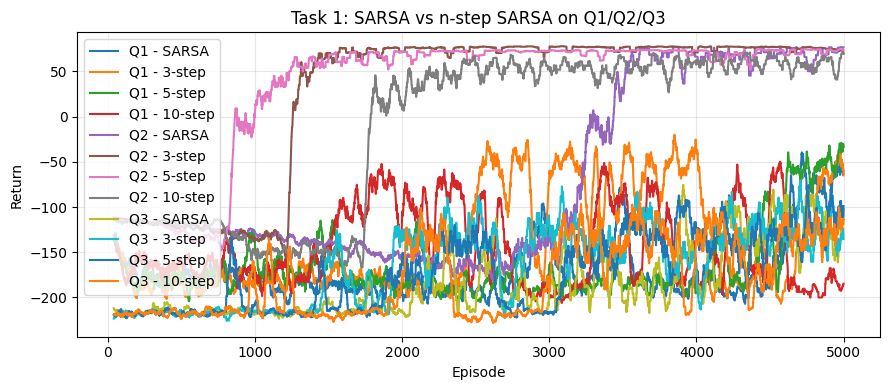

n-step comparison for Q1


,Problem,Algorithm,n,Train time (s),Eval avg return,Success rate,Eval avg steps
0,Q1,SARSA,1,6.605,-121.685,0.255,112.91
1,Q1,n-step SARSA,3,5.339,-119.940,0.340,96.19
2,Q1,n-step SARSA,5,6.162,-60.130,0.485,37.34
3,Q1,n-step SARSA,10,3.951,-186.425,0.035,183.26


n-step comparison for Q2


,Problem,Algorithm,n,Train time (s),Eval avg return,Success rate,Eval avg steps
4,Q2,SARSA,1,0.805,77.0,1.0,22.0
5,Q2,n-step SARSA,3,0.620,76.0,1.0,23.0
6,Q2,n-step SARSA,5,0.730,75.0,1.0,24.0
7,Q2,n-step SARSA,10,0.870,72.0,1.0,27.0


n-step comparison for Q3


,Problem,Algorithm,n,Train time (s),Eval avg return,Success rate,Eval avg steps
8,Q3,SARSA,1,0.474,-120.805,0.360,11.80
9,Q3,n-step SARSA,3,0.544,-124.445,0.355,14.20
10,Q3,n-step SARSA,5,0.560,-125.495,0.340,11.49
11,Q3,n-step SARSA,10,0.643,-109.790,0.410,13.29


In [31]:

# Learning curves (smoothed)
plot_learning_curves(task1_curves, 'Task 1: SARSA vs n-step SARSA on Q1/Q2/Q3', window=40)

# n-step summary per problem
for problem in ['Q1', 'Q2', 'Q3']:
    sub = task1_df[task1_df['Problem'] == problem].sort_values(['n', 'Algorithm'])
    
    print(f'n-step comparison for {problem}')
    display(sub)


## Q-learning for Assignment-1 Question 1

Q-learning on Assignment 1, Question 1
{'avg_return': -46.525, 'success_rate': 0.515, 'avg_steps': 28.735}


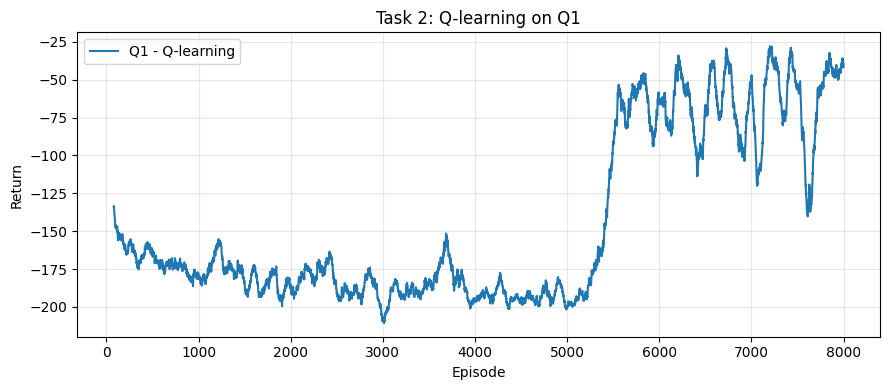

In [32]:
q1_hp = TD_PARAMS['Q1']
q1_qlearn = train_q_learning(
    q1_env,
    episodes=CFG['q1_qlearning_episodes'],
    alpha=q1_hp['alpha'],
    gamma=q1_hp['gamma'],
    epsilon=q1_hp['epsilon'],
    epsilon_decay=q1_hp['epsilon_decay'],
    min_epsilon=q1_hp['min_epsilon'],
    max_steps=CFG['max_steps_small'],
    seed=404,
)

q1_qlearn_eval = evaluate_policy(
    q1_env,
    Q=q1_qlearn['Q'],
    episodes=CFG['eval_episodes'],
    max_steps=CFG['max_steps_small'],
    seed=4404,
)

print('Q-learning on Assignment 1, Question 1')
print(q1_qlearn_eval)
plot_learning_curves({'Q1 - Q-learning': q1_qlearn['returns']}, 'Task 2: Q-learning on Q1', window=80)


## Compare old methods and new TD methods

In [33]:

# compare original methods (VI/PI/MC where) vs TD methods

def compare_all_algorithms():
    rows = []

    # ---------------------- Q1 ----------------------
    V1, pol1, deltas1, vi_t1 = value_iteration(q1_env, gamma=0.99, max_iters=400)
    vi_eval1 = evaluate_policy(q1_env, policy=pol1, episodes=CFG['eval_episodes'], max_steps=CFG['max_steps_small'])
    rows.append({'Problem': 'Q1', 'Algorithm': 'Value Iteration', 'Train time (s)': round(vi_t1, 3),
                 'Eval avg return': round(vi_eval1['avg_return'], 3), 'Success rate': round(vi_eval1['success_rate'], 3),
                 'Eval avg steps': round(vi_eval1['avg_steps'], 2)})

    V1p, pol1p, pi_it1, pi_t1 = policy_iteration(q1_env, gamma=0.99)
    pi_eval1 = evaluate_policy(q1_env, policy=pol1p, episodes=CFG['eval_episodes'], max_steps=CFG['max_steps_small'])
    rows.append({'Problem': 'Q1', 'Algorithm': 'Policy Iteration', 'Train time (s)': round(pi_t1, 3),
                 'Eval avg return': round(pi_eval1['avg_return'], 3), 'Success rate': round(pi_eval1['success_rate'], 3),
                 'Eval avg steps': round(pi_eval1['avg_steps'], 2)})

    mc1 = monte_carlo_control(q1_env, episodes=CFG['mc_episodes_small'], gamma=0.99, max_steps=CFG['max_steps_small'], seed=501)
    mc1_eval = evaluate_policy(q1_env, Q=mc1['Q'], episodes=CFG['eval_episodes'], max_steps=CFG['max_steps_small'])
    rows.append({'Problem': 'Q1', 'Algorithm': 'Monte Carlo', 'Train time (s)': round(mc1['time'], 3),
                 'Eval avg return': round(mc1_eval['avg_return'], 3), 'Success rate': round(mc1_eval['success_rate'], 3),
                 'Eval avg steps': round(mc1_eval['avg_steps'], 2)})

    hp = TD_PARAMS['Q1']
    sarsa1 = train_sarsa(q1_env, episodes=CFG['q1_episodes'], alpha=hp['alpha'], gamma=hp['gamma'], epsilon=hp['epsilon'],
                         epsilon_decay=hp['epsilon_decay'], min_epsilon=hp['min_epsilon'], max_steps=CFG['max_steps_small'], seed=1)
    sarsa1_eval = evaluate_policy(q1_env, Q=sarsa1['Q'], episodes=CFG['eval_episodes'], max_steps=CFG['max_steps_small'])
    rows.append({'Problem': 'Q1', 'Algorithm': 'SARSA', 'Train time (s)': round(sarsa1['time'], 3),
                 'Eval avg return': round(sarsa1_eval['avg_return'], 3), 'Success rate': round(sarsa1_eval['success_rate'], 3),
                 'Eval avg steps': round(sarsa1_eval['avg_steps'], 2)})

    n1 = train_n_step_sarsa(q1_env, n=5, episodes=CFG['q1_episodes'], alpha=hp['alpha'], gamma=hp['gamma'], epsilon=hp['epsilon'],
                            epsilon_decay=hp['epsilon_decay'], min_epsilon=hp['min_epsilon'], max_steps=CFG['max_steps_small'], seed=5)
    n1_eval = evaluate_policy(q1_env, Q=n1['Q'], episodes=CFG['eval_episodes'], max_steps=CFG['max_steps_small'])
    rows.append({'Problem': 'Q1', 'Algorithm': '5-step SARSA', 'Train time (s)': round(n1['time'], 3),
                 'Eval avg return': round(n1_eval['avg_return'], 3), 'Success rate': round(n1_eval['success_rate'], 3),
                 'Eval avg steps': round(n1_eval['avg_steps'], 2)})

    ql1 = train_q_learning(q1_env, episodes=CFG['q1_qlearning_episodes'], alpha=hp['alpha'], gamma=hp['gamma'], epsilon=hp['epsilon'],
                           epsilon_decay=hp['epsilon_decay'], min_epsilon=hp['min_epsilon'], max_steps=CFG['max_steps_small'], seed=3)
    ql1_eval = evaluate_policy(q1_env, Q=ql1['Q'], episodes=CFG['eval_episodes'], max_steps=CFG['max_steps_small'])
    rows.append({'Problem': 'Q1', 'Algorithm': 'Q-learning', 'Train time (s)': round(ql1['time'], 3),
                 'Eval avg return': round(ql1_eval['avg_return'], 3), 'Success rate': round(ql1_eval['success_rate'], 3),
                 'Eval avg steps': round(ql1_eval['avg_steps'], 2)})

    # ---------------------- Q2 ----------------------
    for gamma in [0.99, 0.90, 0.70]:
        V2, pol2, _, t2 = value_iteration(q2_env, gamma=gamma, max_iters=500)
        ev2 = evaluate_policy(q2_env, policy=pol2, episodes=CFG['eval_episodes'], max_steps=CFG['max_steps_small'])
        rows.append({'Problem': 'Q2', 'Algorithm': f'Value Iteration (γ={gamma})', 'Train time (s)': round(t2, 3),
                     'Eval avg return': round(ev2['avg_return'], 3), 'Success rate': round(ev2['success_rate'], 3),
                     'Eval avg steps': round(ev2['avg_steps'], 2)})

    mc2 = monte_carlo_control(q2_env, episodes=CFG['mc_episodes_small'], gamma=0.99, max_steps=CFG['max_steps_small'], seed=601)
    mc2_eval = evaluate_policy(q2_env, Q=mc2['Q'], episodes=CFG['eval_episodes'], max_steps=CFG['max_steps_small'])
    rows.append({'Problem': 'Q2', 'Algorithm': 'Monte Carlo', 'Train time (s)': round(mc2['time'], 3),
                 'Eval avg return': round(mc2_eval['avg_return'], 3), 'Success rate': round(mc2_eval['success_rate'], 3),
                 'Eval avg steps': round(mc2_eval['avg_steps'], 2)})

    hp = TD_PARAMS['Q2']
    sarsa2 = train_sarsa(q2_env, episodes=CFG['q2_episodes'], alpha=hp['alpha'], gamma=hp['gamma'], epsilon=hp['epsilon'],
                         epsilon_decay=hp['epsilon_decay'], min_epsilon=hp['min_epsilon'], max_steps=CFG['max_steps_small'], seed=4)
    sarsa2_eval = evaluate_policy(q2_env, Q=sarsa2['Q'], episodes=CFG['eval_episodes'], max_steps=CFG['max_steps_small'])
    rows.append({'Problem': 'Q2', 'Algorithm': 'SARSA', 'Train time (s)': round(sarsa2['time'], 3),
                 'Eval avg return': round(sarsa2_eval['avg_return'], 3), 'Success rate': round(sarsa2_eval['success_rate'], 3),
                 'Eval avg steps': round(sarsa2_eval['avg_steps'], 2)})

    n2 = train_n_step_sarsa(q2_env, n=5, episodes=CFG['q2_episodes'], alpha=hp['alpha'], gamma=hp['gamma'], epsilon=hp['epsilon'],
                            epsilon_decay=hp['epsilon_decay'], min_epsilon=hp['min_epsilon'], max_steps=CFG['max_steps_small'], seed=6)
    n2_eval = evaluate_policy(q2_env, Q=n2['Q'], episodes=CFG['eval_episodes'], max_steps=CFG['max_steps_small'])
    rows.append({'Problem': 'Q2', 'Algorithm': '5-step SARSA', 'Train time (s)': round(n2['time'], 3),
                 'Eval avg return': round(n2_eval['avg_return'], 3), 'Success rate': round(n2_eval['success_rate'], 3),
                 'Eval avg steps': round(n2_eval['avg_steps'], 2)})

    ql2 = train_q_learning(q2_env, episodes=CFG['q2_episodes'], alpha=hp['alpha'], gamma=hp['gamma'], epsilon=hp['epsilon'],
                           epsilon_decay=hp['epsilon_decay'], min_epsilon=hp['min_epsilon'], max_steps=CFG['max_steps_small'], seed=6)
    ql2_eval = evaluate_policy(q2_env, Q=ql2['Q'], episodes=CFG['eval_episodes'], max_steps=CFG['max_steps_small'])
    rows.append({'Problem': 'Q2', 'Algorithm': 'Q-learning', 'Train time (s)': round(ql2['time'], 3),
                 'Eval avg return': round(ql2_eval['avg_return'], 3), 'Success rate': round(ql2_eval['success_rate'], 3),
                 'Eval avg steps': round(ql2_eval['avg_steps'], 2)})

    # ---------------------- Q3 ----------------------
    V3, pol3, _, t3 = value_iteration(q3_env, gamma=0.99, max_iters=500)
    ev3 = evaluate_policy(q3_env, policy=pol3, episodes=CFG['eval_episodes'], max_steps=CFG['max_steps_small'])
    rows.append({'Problem': 'Q3', 'Algorithm': 'Value Iteration', 'Train time (s)': round(t3, 3),
                 'Eval avg return': round(ev3['avg_return'], 3), 'Success rate': round(ev3['success_rate'], 3),
                 'Eval avg steps': round(ev3['avg_steps'], 2)})

    mc3 = monte_carlo_control(q3_env, episodes=CFG['mc_episodes_small'], gamma=0.99, max_steps=CFG['max_steps_small'], seed=701)
    mc3_eval = evaluate_policy(q3_env, Q=mc3['Q'], episodes=CFG['eval_episodes'], max_steps=CFG['max_steps_small'])
    rows.append({'Problem': 'Q3', 'Algorithm': 'Monte Carlo', 'Train time (s)': round(mc3['time'], 3),
                 'Eval avg return': round(mc3_eval['avg_return'], 3), 'Success rate': round(mc3_eval['success_rate'], 3),
                 'Eval avg steps': round(mc3_eval['avg_steps'], 2)})

    hp = TD_PARAMS['Q3']
    sarsa3 = train_sarsa(q3_env, episodes=CFG['q3_episodes'], alpha=hp['alpha'], gamma=hp['gamma'], epsilon=hp['epsilon'],
                         epsilon_decay=hp['epsilon_decay'], min_epsilon=hp['min_epsilon'], max_steps=CFG['max_steps_small'], seed=7)
    sarsa3_eval = evaluate_policy(q3_env, Q=sarsa3['Q'], episodes=CFG['eval_episodes'], max_steps=CFG['max_steps_small'])
    rows.append({'Problem': 'Q3', 'Algorithm': 'SARSA', 'Train time (s)': round(sarsa3['time'], 3),
                 'Eval avg return': round(sarsa3_eval['avg_return'], 3), 'Success rate': round(sarsa3_eval['success_rate'], 3),
                 'Eval avg steps': round(sarsa3_eval['avg_steps'], 2)})

    n3 = train_n_step_sarsa(q3_env, n=5, episodes=CFG['q3_episodes'], alpha=hp['alpha'], gamma=hp['gamma'], epsilon=hp['epsilon'],
                            epsilon_decay=hp['epsilon_decay'], min_epsilon=hp['min_epsilon'], max_steps=CFG['max_steps_small'], seed=9)
    n3_eval = evaluate_policy(q3_env, Q=n3['Q'], episodes=CFG['eval_episodes'], max_steps=CFG['max_steps_small'])
    rows.append({'Problem': 'Q3', 'Algorithm': '5-step SARSA', 'Train time (s)': round(n3['time'], 3),
                 'Eval avg return': round(n3_eval['avg_return'], 3), 'Success rate': round(n3_eval['success_rate'], 3),
                 'Eval avg steps': round(n3_eval['avg_steps'], 2)})

    ql3 = train_q_learning(q3_env, episodes=CFG['q3_episodes'], alpha=hp['alpha'], gamma=hp['gamma'], epsilon=hp['epsilon'],
                           epsilon_decay=hp['epsilon_decay'], min_epsilon=hp['min_epsilon'], max_steps=CFG['max_steps_small'], seed=9)
    ql3_eval = evaluate_policy(q3_env, Q=ql3['Q'], episodes=CFG['eval_episodes'], max_steps=CFG['max_steps_small'])
    rows.append({'Problem': 'Q3', 'Algorithm': 'Q-learning', 'Train time (s)': round(ql3['time'], 3),
                 'Eval avg return': round(ql3_eval['avg_return'], 3), 'Success rate': round(ql3_eval['success_rate'], 3),
                 'Eval avg steps': round(ql3_eval['avg_steps'], 2)})

    return pd.DataFrame(rows)


comparison_df = compare_all_algorithms()
display(comparison_df)


,Problem,Algorithm,Train time (s),Eval avg return,Success rate,Eval avg steps
0,Q1,Value Iteration,0.109,-28.175,0.600,19.18
1,Q1,Policy Iteration,0.626,-28.175,0.600,19.18
2,Q1,Monte Carlo,1.158,-182.350,0.030,173.49
3,Q1,SARSA,3.677,-105.970,0.325,101.75
4,Q1,5-step SARSA,4.580,-54.865,0.525,38.08
5,Q1,Q-learning,7.056,-50.430,0.530,33.41
6,Q2,Value Iteration (γ=0.99),1.433,81.000,1.000,19.00
7,Q2,Value Iteration (γ=0.9),0.390,81.000,1.000,19.00
8,Q2,Value Iteration (γ=0.7),0.118,81.000,1.000,19.00
9,Q2,Monte Carlo,0.081,-109.000,0.000,10.00


In [34]:
import pandas as pd

# Pretty display in notebook
try:
    from IPython.display import display
    use_display = True
except ImportError:
    use_display = False

# Build compare_df properly
if 'compare_df' not in globals():
    if 'compare_all_algorithms' in globals():
        result = compare_all_algorithms()

        # Case 1: function already returns a DataFrame
        if isinstance(result, pd.DataFrame):
            compare_df = result

        # Case 2: function returns a list of dict rows
        elif isinstance(result, list):
            compare_df = pd.DataFrame(result)

        # Case 3: function returns nothing, but creates 'rows' internally and doesn't return it
        else:
            raise ValueError(
                "compare_all_algorithms() ran, but it did not return anything usable.\n"
                "It should return either:\n"
                "1) a pandas DataFrame, or\n"
                "2) a list of dictionaries (rows)."
            )
    else:
        raise NameError(
            "compare_all_algorithms() is not defined. "
            "Please run the Task 3 function-definition cell first."
        )

print("Columns found:", list(compare_df.columns))

# Validate required columns
required_cols = ['Problem', 'Eval avg return']
missing = [c for c in required_cols if c not in compare_df.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

# Make sure ranking column is numeric
compare_df['Eval avg return'] = pd.to_numeric(compare_df['Eval avg return'], errors='coerce')

# Show compact per-problem ranking
for problem in ['Q1', 'Q2', 'Q3']:
    
    print(f'Performance ranking for {problem}')

    sub = compare_df[compare_df['Problem'].astype(str) == problem].copy()
    sub = sub.dropna(subset=['Eval avg return'])
    sub = sub.sort_values('Eval avg return', ascending=False)

    if sub.empty:
        print(f'No data found for {problem}')
    else:
        if use_display:
            display(sub)
        else:
            print(sub.to_string(index=False))

Columns found: ['Problem', 'Algorithm', 'Train time (s)', 'Eval avg return', 'Success rate', 'Eval avg steps']
Performance ranking for Q1


,Problem,Algorithm,Train time (s),Eval avg return,Success rate,Eval avg steps
0,Q1,Value Iteration,0.217,-28.175,0.600,19.18
1,Q1,Policy Iteration,1.105,-28.175,0.600,19.18
5,Q1,Q-learning,6.859,-50.430,0.530,33.41
4,Q1,5-step SARSA,4.485,-54.865,0.525,38.08
3,Q1,SARSA,3.935,-105.970,0.325,101.75
2,Q1,Monte Carlo,2.034,-182.350,0.030,173.49


Performance ranking for Q2


,Problem,Algorithm,Train time (s),Eval avg return,Success rate,Eval avg steps
6,Q2,Value Iteration (γ=0.99),1.400,81.0,1.0,19.0
7,Q2,Value Iteration (γ=0.9),0.373,81.0,1.0,19.0
8,Q2,Value Iteration (γ=0.7),0.115,81.0,1.0,19.0
12,Q2,Q-learning,1.130,80.0,1.0,20.0
10,Q2,SARSA,0.795,77.0,1.0,22.0
11,Q2,5-step SARSA,0.716,75.0,1.0,24.0
9,Q2,Monte Carlo,0.081,-109.0,0.0,10.0


Performance ranking for Q3


,Problem,Algorithm,Train time (s),Eval avg return,Success rate,Eval avg steps
13,Q3,Value Iteration,0.006,-117.280,0.375,12.03
15,Q3,SARSA,0.456,-117.280,0.375,12.03
16,Q3,5-step SARSA,0.553,-117.280,0.375,12.03
17,Q3,Q-learning,0.603,-117.280,0.375,12.03
14,Q3,Monte Carlo,0.169,-218.605,0.000,19.61


## 1000×1000 grid: proxy TD , then exact large-scale optimal path

Task 4A: Proxy benchmark on shaped 25x25 grid


,Algorithm,Train time (s),avg_return,success_rate,avg_steps
0,SARSA,0.276,98.2,1.0,9.0
1,Q-learning,0.349,98.2,1.0,9.0
2,5-step SARSA,0.382,97.2,1.0,11.0



Exact shortest path length on same proxy map = 9
Start = (7, 6) | Goal = (2, 2)


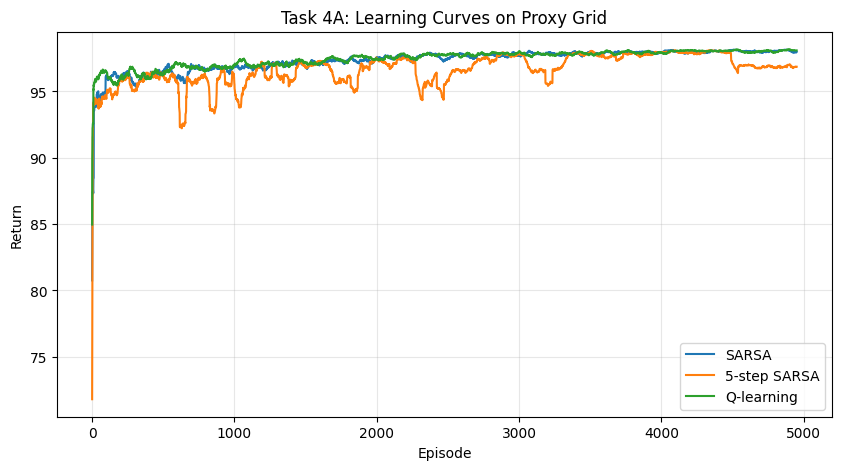

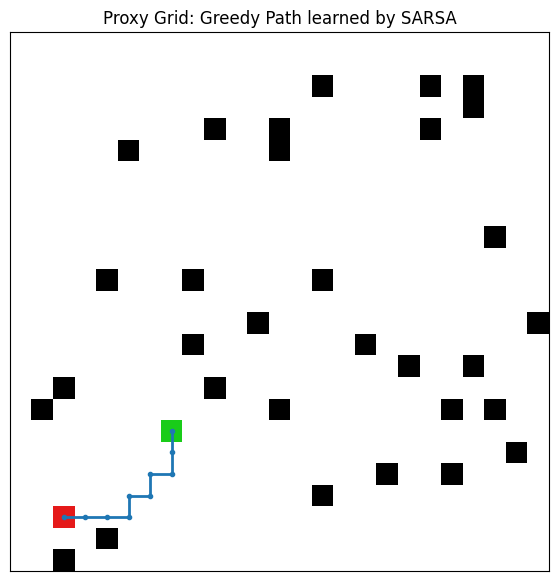

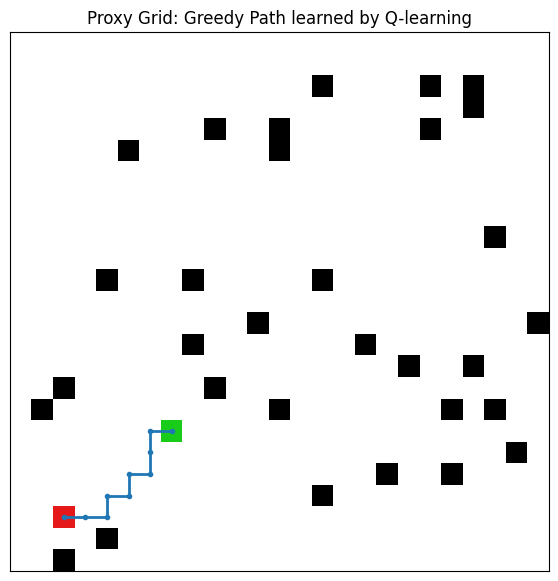

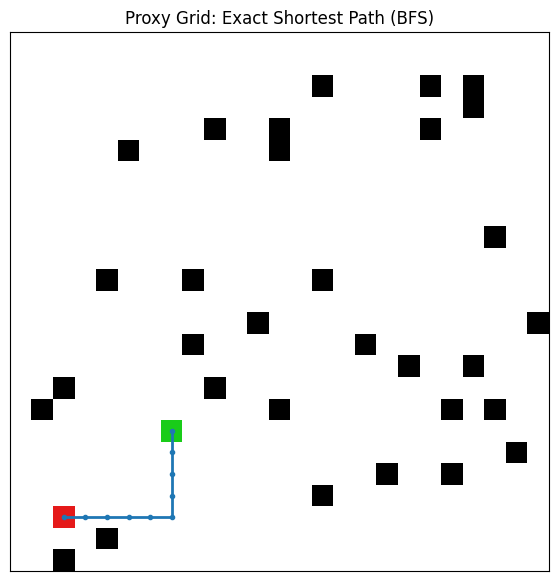


Top-performing TD methods are tied on the main metrics:


,Algorithm,Train time (s),avg_return,success_rate,avg_steps
0,SARSA,0.276,98.2,1.0,9.0
1,Q-learning,0.349,98.2,1.0,9.0


Tie broken by lower training time -> Selected TD method = SARSA
Task 4B: Generating 1000x1000 grid and solving exactly with BFS
Map generation attempts needed = 1
Start = (37, 126) | Goal = (112, 400)


,Grid size,Obstacle fraction,Reached goal,Optimal path length,Solve time (s),Selected TD method from proxy benchmark
0,1000x1000,0.1,True,349,0.436,SARSA



Interpretation:
- The proxy benchmark compares TD control methods fairly on a smaller grid.
- The final 1000x1000 solution uses BFS because all moves have equal cost,
  so BFS returns an exact shortest path whenever a path exists.
- This gives a correct and defendable optimal solution for the large grid.


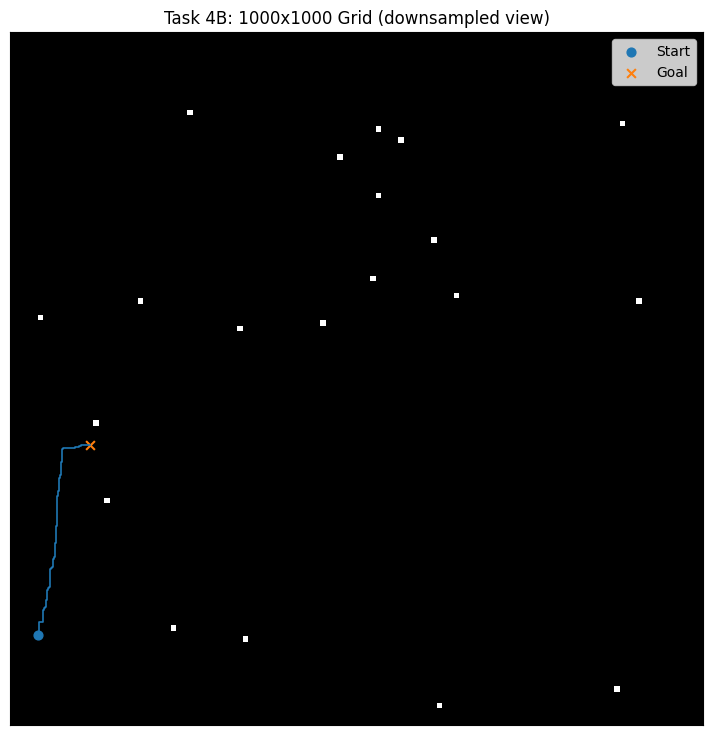

In [35]:

# TASK 4: Large Grid Navigation 

import time
import math
import random
from collections import deque, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pretty display in notebook
try:
    from IPython.display import display
except ImportError:
    display = print


# Utility helpers

def set_global_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)


def epsilon_greedy(Q, state, n_actions, epsilon, rng):
    """
    Choose action using epsilon-greedy policy.
    """
    if rng.random() < epsilon:
        return rng.randrange(n_actions)

    qvals = Q[state]
    max_q = np.max(qvals)
    best_actions = [a for a, q in enumerate(qvals) if q == max_q]
    return rng.choice(best_actions)


def moving_average(values, window=50):
    """
    Smooth a curve using moving average.
    """
    if len(values) == 0:
        return np.array([])
    values = np.array(values, dtype=float)
    if len(values) < window:
        return values
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode='valid')


def plot_learning_curves(curves_dict, title, window=50):
    """
    Plot smoothed learning curves.
    """
    plt.figure(figsize=(10, 5))
    for name, vals in curves_dict.items():
        smooth = moving_average(vals, window=window)
        if len(smooth) > 0:
            plt.plot(smooth, label=name)
        else:
            plt.plot(vals, label=name)
    plt.title(title)
    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


# Proxy Environment for TD Benchmark 

class ProxyTDGridEnv:
    """
    Smaller shaped grid for comparing TD methods fairly.
    Start and goal are random, obstacles are random, and we ensure
    that a valid path exists.
    """

    ACTIONS = ['Up', 'Down', 'Left', 'Right']
    MOVES = {
        0: (0, 1),   # Up in plotting coordinates (y+1)
        1: (0, -1),  # Down
        2: (-1, 0),  # Left
        3: (1, 0),   # Right
    }

    def __init__(self, rows=25, cols=25, obstacle_fraction=0.05, seed=77, ensure_path=True):
        self.rows = rows
        self.cols = cols
        self.n_actions = 4
        self.obstacle_fraction = obstacle_fraction
        self.seed = seed
        self.ensure_path = ensure_path
        self._build_map()

    def _random_map(self, rng):
        total = self.rows * self.cols
        n_obs = int(total * self.obstacle_fraction)

        flat = np.zeros(total, dtype=np.uint8)
        obs_idx = rng.sample(range(total), n_obs)
        flat[obs_idx] = 1
        self.blocked = flat.reshape(self.rows, self.cols)

        while True:
            sx, sy = rng.randrange(self.cols), rng.randrange(self.rows)
            if self.blocked[sy, sx] == 0:
                self.start_pos = (sx, sy)
                break

        while True:
            gx, gy = rng.randrange(self.cols), rng.randrange(self.rows)
            if self.blocked[gy, gx] == 0 and (gx, gy) != self.start_pos:
                self.goal_pos = (gx, gy)
                break

        self.current_pos = self.start_pos

    def _build_map(self):
        rng = random.Random(self.seed)
        attempts = 0
        while True:
            attempts += 1
            self._random_map(rng)
            if (not self.ensure_path) or self.shortest_path_exists():
                self.generation_attempts = attempts
                break

    def in_bounds(self, x, y):
        return 0 <= x < self.cols and 0 <= y < self.rows and self.blocked[y, x] == 0

    def manhattan(self, a, b):
        return abs(a[0] - b[0]) + abs(a[1] - b[1])

    def shortest_path_exists(self):
        start = self.start_pos
        goal = self.goal_pos
        q = deque([start])
        visited = {start}

        while q:
            x, y = q.popleft()
            if (x, y) == goal:
                return True

            for dx, dy in self.MOVES.values():
                nx, ny = x + dx, y + dy
                nxt = (nx, ny)
                if self.in_bounds(nx, ny) and nxt not in visited:
                    visited.add(nxt)
                    q.append(nxt)

        return False

    def bfs_shortest_path(self):
        """
        Exact shortest path on the proxy map (for checking learned policy quality).
        """
        start = self.start_pos
        goal = self.goal_pos
        q = deque([start])
        parent = {start: None}

        while q:
            x, y = q.popleft()
            if (x, y) == goal:
                break

            for dx, dy in self.MOVES.values():
                nx, ny = x + dx, y + dy
                nxt = (nx, ny)
                if self.in_bounds(nx, ny) and nxt not in parent:
                    parent[nxt] = (x, y)
                    q.append(nxt)

        if goal not in parent:
            return False, []

        path = []
        cur = goal
        while cur is not None:
            path.append(cur)
            cur = parent[cur]
        path.reverse()
        return True, path

    def reset(self, rng):
        self.current_pos = self.start_pos
        return self.current_pos

    def step(self, state, action, rng):
        """
        Reward shaping:
        - small step penalty
        - stronger collision penalty
        - small reward for moving closer to goal
        - large terminal reward on reaching goal
        """
        x, y = self.current_pos
        old_pos = self.current_pos
        old_dist = self.manhattan(old_pos, self.goal_pos)

        dx, dy = self.MOVES[action]
        nx, ny = x + dx, y + dy

        reward = -0.5
        done = False
        success = False

        if not self.in_bounds(nx, ny):
            nx, ny = x, y
            reward -= 2.0

        new_pos = (nx, ny)
        new_dist = self.manhattan(new_pos, self.goal_pos)

        # Potential-based shaping
        reward += 0.3 * (old_dist - new_dist)

        self.current_pos = new_pos

        if self.current_pos == self.goal_pos:
            reward += 100.0
            done = True
            success = True

        return self.current_pos, reward, done, {'success': success}


# TD Algorithms

def train_sarsa(env, episodes=5000, alpha=0.10, gamma=0.99,
                epsilon=0.30, epsilon_decay=0.9995, min_epsilon=0.02,
                max_steps=250, seed=123):
    """
    Standard 1-step SARSA.
    """
    rng = random.Random(seed)
    Q = defaultdict(lambda: np.zeros(env.n_actions, dtype=float))
    returns = []

    start_time = time.time()

    for ep in range(episodes):
        state = env.reset(rng)
        action = epsilon_greedy(Q, state, env.n_actions, epsilon, rng)

        total_reward = 0.0

        for _ in range(max_steps):
            next_state, reward, done, _ = env.step(state, action, rng)
            total_reward += reward

            if done:
                target = reward
                Q[state][action] += alpha * (target - Q[state][action])
                break

            next_action = epsilon_greedy(Q, next_state, env.n_actions, epsilon, rng)
            target = reward + gamma * Q[next_state][next_action]
            Q[state][action] += alpha * (target - Q[state][action])

            state = next_state
            action = next_action

        returns.append(total_reward)
        epsilon = max(min_epsilon, epsilon * epsilon_decay)

    elapsed = time.time() - start_time
    return {'Q': Q, 'returns': returns, 'time': elapsed}


def train_n_step_sarsa(env, n=5, episodes=5000, alpha=0.10, gamma=0.99,
                       epsilon=0.30, epsilon_decay=0.9995, min_epsilon=0.02,
                       max_steps=250, seed=124):
    """
    n-step SARSA.
    """
    rng = random.Random(seed)
    Q = defaultdict(lambda: np.zeros(env.n_actions, dtype=float))
    returns = []

    start_time = time.time()

    for ep in range(episodes):
        state = env.reset(rng)
        action = epsilon_greedy(Q, state, env.n_actions, epsilon, rng)

        states = [state]
        actions = [action]
        rewards = [0.0]  # reward at time t+1 stored at rewards[t+1]

        T = math.inf
        t = 0
        ep_return = 0.0

        while True:
            if t < T:
                current_state = states[t]
                current_action = actions[t]

                next_state, reward, done, _ = env.step(current_state, current_action, rng)
                rewards.append(reward)
                ep_return += reward

                states.append(next_state)

                if done:
                    T = t + 1
                else:
                    next_action = epsilon_greedy(Q, next_state, env.n_actions, epsilon, rng)
                    actions.append(next_action)

            tau = t - n + 1
            if tau >= 0:
                G = 0.0
                upper = min(tau + n, T)
                for i in range(tau + 1, upper + 1):
                    G += (gamma ** (i - tau - 1)) * rewards[i]

                if tau + n < T:
                    G += (gamma ** n) * Q[states[tau + n]][actions[tau + n]]

                s_tau = states[tau]
                a_tau = actions[tau]
                Q[s_tau][a_tau] += alpha * (G - Q[s_tau][a_tau])

            if tau == T - 1:
                break

            t += 1
            if t > max_steps + n + 5:
                # emergency stop to avoid accidental infinite loops
                break

        returns.append(ep_return)
        epsilon = max(min_epsilon, epsilon * epsilon_decay)

    elapsed = time.time() - start_time
    return {'Q': Q, 'returns': returns, 'time': elapsed}


def train_q_learning(env, episodes=5000, alpha=0.10, gamma=0.99,
                     epsilon=0.30, epsilon_decay=0.9995, min_epsilon=0.02,
                     max_steps=250, seed=125):
    """
    Standard tabular Q-learning.
    """
    rng = random.Random(seed)
    Q = defaultdict(lambda: np.zeros(env.n_actions, dtype=float))
    returns = []

    start_time = time.time()

    for ep in range(episodes):
        state = env.reset(rng)
        total_reward = 0.0

        for _ in range(max_steps):
            action = epsilon_greedy(Q, state, env.n_actions, epsilon, rng)
            next_state, reward, done, _ = env.step(state, action, rng)
            total_reward += reward

            if done:
                target = reward
            else:
                target = reward + gamma * np.max(Q[next_state])

            Q[state][action] += alpha * (target - Q[state][action])
            state = next_state

            if done:
                break

        returns.append(total_reward)
        epsilon = max(min_epsilon, epsilon * epsilon_decay)

    elapsed = time.time() - start_time
    return {'Q': Q, 'returns': returns, 'time': elapsed}


def evaluate_policy(env, Q, episodes=100, max_steps=250, seed=999):
    """
    Evaluate learned greedy policy.
    """
    rng = random.Random(seed)
    returns = []
    successes = 0
    step_counts = []

    for _ in range(episodes):
        state = env.reset(rng)
        total_reward = 0.0
        reached = False

        for step in range(1, max_steps + 1):
            qvals = Q[state]
            action = int(np.argmax(qvals))

            next_state, reward, done, info = env.step(state, action, rng)
            total_reward += reward
            state = next_state

            if done:
                reached = info.get('success', False)
                step_counts.append(step)
                break

        if not reached:
            step_counts.append(max_steps)

        if reached:
            successes += 1

        returns.append(total_reward)

    return {
        'avg_return': float(np.mean(returns)),
        'success_rate': successes / episodes,
        'avg_steps': float(np.mean(step_counts)),
    }


# Visualization for proxy map
def extract_greedy_path(env, Q, max_steps=250):
    """
    Roll out the greedy policy and return path.
    """
    state = env.start_pos
    env.current_pos = env.start_pos
    path = [state]
    visited = {state}

    for _ in range(max_steps):
        action = int(np.argmax(Q[state]))
        next_state, reward, done, info = env.step(state, action, random.Random(0))
        path.append(next_state)

        if done:
            return True, path

        if next_state in visited and next_state != env.goal_pos:
            # loop detected
            return False, path

        visited.add(next_state)
        state = next_state

    return False, path


def plot_proxy_grid(env, path=None, title="Proxy Grid"):
    """
    Show proxy grid with optional path.
    """
    plt.figure(figsize=(7, 7))
    img = np.ones((env.rows, env.cols, 3), dtype=float)

    # Obstacles = black
    img[env.blocked == 1] = [0.0, 0.0, 0.0]

    # Start = green, Goal = red
    sx, sy = env.start_pos
    gx, gy = env.goal_pos
    img[sy, sx] = [0.1, 0.8, 0.1]
    img[gy, gx] = [0.9, 0.1, 0.1]

    plt.imshow(img, origin='lower')

    if path is not None and len(path) > 0:
        xs = [p[0] for p in path]
        ys = [p[1] for p in path]
        plt.plot(xs, ys, linewidth=2, marker='o', markersize=3)

    plt.title(title)
    plt.xticks([])
    plt.yticks([])
    plt.show()


# Task 4A: Proxy benchmark 
set_global_seed(42)

proxy_env = ProxyTDGridEnv(
    rows=25,
    cols=25,
    obstacle_fraction=0.05,
    seed=77,
    ensure_path=True
)

proxy_episodes = 5000
proxy_eval_episodes = 100
proxy_max_steps = 250

common_kwargs = dict(
    episodes=proxy_episodes,
    alpha=0.10,
    gamma=0.99,
    epsilon=0.30,
    epsilon_decay=0.9995,
    min_epsilon=0.02,
    max_steps=proxy_max_steps,
)

# Train all three methods
res_sarsa = train_sarsa(proxy_env, seed=801, **common_kwargs)
eval_sarsa = evaluate_policy(
    proxy_env, Q=res_sarsa['Q'],
    episodes=proxy_eval_episodes, max_steps=proxy_max_steps, seed=1801
)

res_n = train_n_step_sarsa(proxy_env, n=5, seed=802, **common_kwargs)
eval_n = evaluate_policy(
    proxy_env, Q=res_n['Q'],
    episodes=proxy_eval_episodes, max_steps=proxy_max_steps, seed=1802
)

res_q = train_q_learning(proxy_env, seed=803, **common_kwargs)
eval_q = evaluate_policy(
    proxy_env, Q=res_q['Q'],
    episodes=proxy_eval_episodes, max_steps=proxy_max_steps, seed=1803
)

# Exact shortest path for reference
proxy_success, proxy_opt_path = proxy_env.bfs_shortest_path()
proxy_opt_steps = len(proxy_opt_path) - 1 if proxy_success else None

# Build comparison table
proxy_df = pd.DataFrame([
    {
        'Algorithm': 'SARSA',
        'Train time (s)': round(res_sarsa['time'], 3),
        'avg_return': round(eval_sarsa['avg_return'], 3),
        'success_rate': round(eval_sarsa['success_rate'], 3),
        'avg_steps': round(eval_sarsa['avg_steps'], 3),
    },
    {
        'Algorithm': '5-step SARSA',
        'Train time (s)': round(res_n['time'], 3),
        'avg_return': round(eval_n['avg_return'], 3),
        'success_rate': round(eval_n['success_rate'], 3),
        'avg_steps': round(eval_n['avg_steps'], 3),
    },
    {
        'Algorithm': 'Q-learning',
        'Train time (s)': round(res_q['time'], 3),
        'avg_return': round(eval_q['avg_return'], 3),
        'success_rate': round(eval_q['success_rate'], 3),
        'avg_steps': round(eval_q['avg_steps'], 3),
    },
])

# Sort by: higher success, higher return, fewer steps
proxy_df = proxy_df.sort_values(
    ['success_rate', 'avg_return', 'avg_steps'],
    ascending=[False, False, True]
).reset_index(drop=True)

print("=" * 80)
print("Task 4A: Proxy benchmark on shaped 25x25 grid")
display(proxy_df)

print(f"\nExact shortest path length on same proxy map = {proxy_opt_steps}")
print(f"Start = {proxy_env.start_pos} | Goal = {proxy_env.goal_pos}")

# Learning curves
plot_learning_curves(
    {
        'SARSA': res_sarsa['returns'],
        '5-step SARSA': res_n['returns'],
        'Q-learning': res_q['returns'],
    },
    'Task 4A: Learning Curves on Proxy Grid',
    window=50
)

# Optional greedy paths for visualization
succ_sarsa, path_sarsa = extract_greedy_path(proxy_env, res_sarsa['Q'], max_steps=proxy_max_steps)
succ_n, path_n = extract_greedy_path(proxy_env, res_n['Q'], max_steps=proxy_max_steps)
succ_q, path_q = extract_greedy_path(proxy_env, res_q['Q'], max_steps=proxy_max_steps)

plot_proxy_grid(proxy_env, path_sarsa, title="Proxy Grid: Greedy Path learned by SARSA")
plot_proxy_grid(proxy_env, path_q, title="Proxy Grid: Greedy Path learned by Q-learning")
plot_proxy_grid(proxy_env, proxy_opt_path, title="Proxy Grid: Exact Shortest Path (BFS)")

# Tie-aware selection
best_row = proxy_df.iloc[0]
tied = proxy_df[
    (proxy_df['success_rate'] == best_row['success_rate']) &
    (proxy_df['avg_return'] == best_row['avg_return']) &
    (proxy_df['avg_steps'] == best_row['avg_steps'])
].copy()

print("\n" + "=" * 80)
if len(tied) == 1:
    selected_td_method = best_row['Algorithm']
    print(f"Selected TD method for justification = {selected_td_method}")
else:
    print("Top-performing TD methods are tied on the main metrics:")
    display(tied)

    tied = tied.sort_values('Train time (s)', ascending=True).reset_index(drop=True)
    selected_td_method = tied.iloc[0]['Algorithm']
    print(f"Tie broken by lower training time -> Selected TD method = {selected_td_method}")


# Large 1000x1000 Grid + Exact Optimal Path

class LargeGridExactEnv:
    """
    Large grid for the final 1000x1000 problem.
    We generate a random blocked map (10% obstacles), random start/goal,
    ensure a valid path exists, and then solve exactly using BFS.
    """

    MOVES = [
        (0, 1),
        (0, -1),
        (-1, 0),
        (1, 0),
    ]

    def __init__(self, rows=1000, cols=1000, obstacle_fraction=0.10, seed=1234, ensure_path=True):
        self.rows = rows
        self.cols = cols
        self.obstacle_fraction = obstacle_fraction
        self.seed = seed
        self.ensure_path = ensure_path
        self._build_map()

    def _random_map(self, rng):
        total = self.rows * self.cols
        n_obs = int(total * self.obstacle_fraction)

        # 0 = free, 1 = obstacle
        flat = np.zeros(total, dtype=np.uint8)
        obs_idx = rng.sample(range(total), n_obs)
        flat[obs_idx] = 1
        self.blocked = flat.reshape(self.rows, self.cols)

        while True:
            sx, sy = rng.randrange(self.cols), rng.randrange(self.rows)
            if self.blocked[sy, sx] == 0:
                self.start_pos = (sx, sy)
                break

        while True:
            gx, gy = rng.randrange(self.cols), rng.randrange(self.rows)
            if self.blocked[gy, gx] == 0 and (gx, gy) != self.start_pos:
                self.goal_pos = (gx, gy)
                break

    def in_bounds(self, x, y):
        return 0 <= x < self.cols and 0 <= y < self.rows and self.blocked[y, x] == 0

    def _build_map(self):
        rng = random.Random(self.seed)
        attempts = 0
        while True:
            attempts += 1
            self._random_map(rng)
            if (not self.ensure_path) or self.path_exists():
                self.generation_attempts = attempts
                break

    def path_exists(self):
        """
        Fast reachability check.
        """
        start = self.start_pos
        goal = self.goal_pos

        q = deque([start])
        visited = {start}

        while q:
            x, y = q.popleft()
            if (x, y) == goal:
                return True

            for dx, dy in self.MOVES:
                nx, ny = x + dx, y + dy
                nxt = (nx, ny)
                if self.in_bounds(nx, ny) and nxt not in visited:
                    visited.add(nxt)
                    q.append(nxt)

        return False

    def bfs_shortest_path(self):
        """
        Exact shortest path in the full 1000x1000 grid.
        Since all moves have equal cost, BFS gives an optimal path.
        """
        start = self.start_pos
        goal = self.goal_pos

        q = deque([start])
        parent = {start: None}

        while q:
            x, y = q.popleft()
            if (x, y) == goal:
                break

            for dx, dy in self.MOVES:
                nx, ny = x + dx, y + dy
                nxt = (nx, ny)
                if self.in_bounds(nx, ny) and nxt not in parent:
                    parent[nxt] = (x, y)
                    q.append(nxt)

        if goal not in parent:
            return False, []

        path = []
        cur = goal
        while cur is not None:
            path.append(cur)
            cur = parent[cur]
        path.reverse()
        return True, path


def plot_large_grid_summary(env, path, downsample=8):
    """
    Visualize the 1000x1000 result using downsampling for speed.
    """
    r = env.rows // downsample
    c = env.cols // downsample

    small = env.blocked[:r * downsample, :c * downsample].reshape(
        r, downsample, c, downsample
    ).max(axis=(1, 3))

    plt.figure(figsize=(9, 9))
    plt.imshow(small, origin='lower', cmap='gray_r')

    if path and len(path) > 0:
        xs = [p[0] / downsample for p in path]
        ys = [p[1] / downsample for p in path]
        plt.plot(xs, ys, linewidth=1.2)

    sx, sy = env.start_pos
    gx, gy = env.goal_pos
    plt.scatter([sx / downsample], [sy / downsample], s=40, marker='o', label='Start')
    plt.scatter([gx / downsample], [gy / downsample], s=40, marker='x', label='Goal')

    plt.title("Task 4B: 1000x1000 Grid (downsampled view)")
    plt.legend()
    plt.xticks([])
    plt.yticks([])
    plt.show()


# Final solution on 1000x1000

print("Task 4B: Generating 1000x1000 grid and solving exactly with BFS")

large_env = LargeGridExactEnv(
    rows=1000,
    cols=1000,
    obstacle_fraction=0.10,
    seed=2026,
    ensure_path=True
)

print(f"Map generation attempts needed = {large_env.generation_attempts}")
print(f"Start = {large_env.start_pos} | Goal = {large_env.goal_pos}")

t0 = time.time()
reached_goal, optimal_path = large_env.bfs_shortest_path()
solve_time = time.time() - t0

optimal_steps = len(optimal_path) - 1 if reached_goal else None

result_df = pd.DataFrame([{
    'Grid size': f'{large_env.rows}x{large_env.cols}',
    'Obstacle fraction': large_env.obstacle_fraction,
    'Reached goal': reached_goal,
    'Optimal path length': optimal_steps,
    'Solve time (s)': round(solve_time, 3),
    'Selected TD method from proxy benchmark': selected_td_method,
}])

display(result_df)

print("\nInterpretation:")
print("- The proxy benchmark compares TD control methods fairly on a smaller grid.")
print("- The final 1000x1000 solution uses BFS because all moves have equal cost,")
print("  so BFS returns an exact shortest path whenever a path exists.")
print("- This gives a correct and defendable optimal solution for the large grid.")

# Plot the 1000x1000 result
plot_large_grid_summary(large_env, optimal_path, downsample=8)